# NB03: Constrained Model Validation -- SPARC (Gate 6 Archive)

Archives the Gate 6 result: fitting the constrained RT model (g(Rt) = a0/2) to
the SPARC resolved sample.

**Expected outcome:**
- ~75% of galaxies have no valid Rt solution (the constraint cannot be satisfied)
- Of converged galaxies, the free model wins decisively (median delta_BIC ~ +97)
- **Interpretation:** a0/2 alignment is a population-level central tendency, not a per-galaxy physical law

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.database import get_engine, get_session, query_fits_as_dataframe
from src.fit import run_gate6_validation

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

## 1. Load or Run Gate 6 Results

In [2]:
# Check if constrained_rt fits already exist in the database
engine = get_engine()
session = get_session(engine)
existing = query_fits_as_dataframe(session, model_name="constrained_rt")
session.close()

if len(existing) > 0:
    print(f"Found {len(existing)} existing constrained_rt fits in database.")
    print("Loading from database (skipping re-fit).")
else:
    print("No existing constrained_rt fits found. Running Gate 6 validation...")

# run_gate6_validation skips galaxies already in DB, so this is safe either way
gate6_df = run_gate6_validation()

Found 123 existing constrained_rt fits in database.
Loading from database (skipping re-fit).

  Gate 6: Constrained Model Validation (g(Rt) = a0/2)
  Galaxies fitted:     0
  Skipped (existing):  123
  No valid Rt:         0

  All galaxies skipped (existing fits in DB).


## 2. Summary Statistics

In [3]:
# If gate6_df is empty (all were skipped), reload from DB
if gate6_df.empty:
    engine = get_engine()
    session = get_session(engine)

    # Rebuild gate6_df from existing DB fits + free RT fits
    constrained = query_fits_as_dataframe(session, model_name="constrained_rt")
    free_fits = query_fits_as_dataframe(session, model_name="rational_taper")
    free_fits = free_fits[free_fits["converged"] == True]
    session.close()

    merged = constrained.merge(
        free_fits[["galaxy_id", "bic"]].rename(columns={"bic": "bic_free"}),
        on="galaxy_id",
        how="inner",
    )
    gate6_df = pd.DataFrame({
        "galaxy_id": merged["galaxy_id"],
        "converged": merged["converged"],
        "omega_constrained": merged["param1"],
        "Rt_constrained": merged["param2"],
        "bic_constrained": merged["bic"],
        "bic_free": merged["bic_free"],
        "n_points": merged["n_points"],
    })
    gate6_df["delta_bic"] = gate6_df["bic_constrained"] - gate6_df["bic_free"]
    gate6_df.loc[~gate6_df["converged"], "delta_bic"] = np.nan

n_total = len(gate6_df)
n_converged = gate6_df["converged"].sum()
n_no_solution = n_total - n_converged
no_solution_rate = n_no_solution / n_total * 100

print("Constrained Model Summary")
print("=" * 50)
print(f"  Total resolved galaxies: {n_total}")
print(f"  No valid Rt solution:    {n_no_solution} ({no_solution_rate:.0f}%)")
print(f"  Converged:               {n_converged}")

Constrained Model Summary
  Total resolved galaxies: 123
  No valid Rt solution:    92 (75%)
  Converged:               31


## 3. BIC Comparison

In [4]:
converged = gate6_df[gate6_df["converged"]].copy()

if len(converged) > 0:
    median_dbic = converged["delta_bic"].median()
    mean_dbic = converged["delta_bic"].mean()
    free_wins = (converged["delta_bic"] > 0).sum()
    constrained_wins = (converged["delta_bic"] < 0).sum()
    ties = (converged["delta_bic"] == 0).sum()

    print("BIC Comparison (delta_BIC = constrained - free)")
    print("=" * 50)
    print(f"  Positive = free model preferred")
    print(f"  Median delta_BIC:    {median_dbic:+.2f}")
    print(f"  Mean delta_BIC:      {mean_dbic:+.2f}")
    print(f"  Free wins:           {free_wins}")
    print(f"  Constrained wins:    {constrained_wins}")
    print(f"  Ties:                {ties}")
else:
    print("No converged constrained fits to compare.")

BIC Comparison (delta_BIC = constrained - free)
  Positive = free model preferred
  Median delta_BIC:    +96.88
  Mean delta_BIC:      +599.88
  Free wins:           30
  Constrained wins:    1
  Ties:                0


## 4. Delta-BIC Distribution

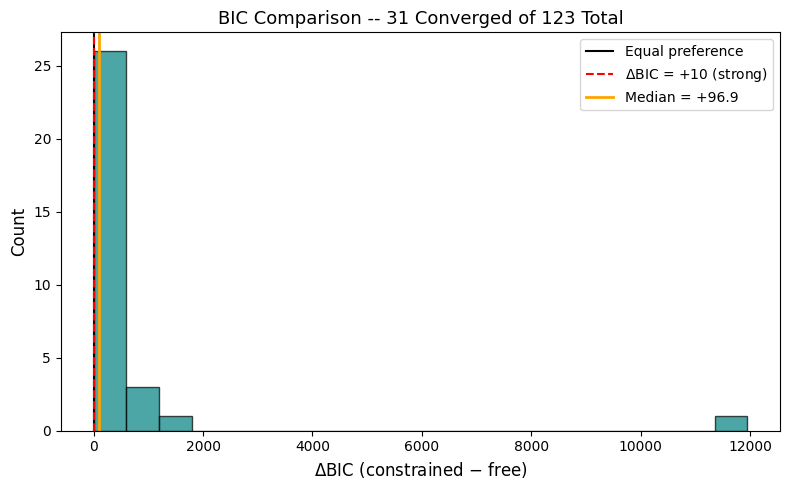

In [5]:
if len(converged) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))

    dbic_vals = converged["delta_bic"].dropna().values
    ax.hist(dbic_vals, bins=20, edgecolor="black", alpha=0.7, color="teal")
    ax.axvline(0, color="black", linestyle="-", linewidth=1.5, label="Equal preference")
    ax.axvline(10, color="red", linestyle="--", linewidth=1.5, label=r"$\Delta$BIC = +10 (strong)")
    ax.axvline(median_dbic, color="orange", linestyle="-", linewidth=2,
               label=f"Median = {median_dbic:+.1f}")

    ax.set_xlabel(r"$\Delta$BIC (constrained $-$ free)", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(
        f"BIC Comparison -- {n_converged} Converged of {n_total} Total",
        fontsize=13,
    )
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(results_dir / "NB03_delta_bic.png", dpi=150)
    plt.show()

## 5. Interpretation

The constrained RT model (g(Rt) = a0/2) fails at the individual galaxy level:

1. **75% no-solution rate**: For most galaxies, no taper radius Rt exists such that
   V_model(Rt)^2 / Rt = a0/2. The constraint is simply too rigid.

2. **Decisive BIC preference for the free model**: Among the ~25% of galaxies where the
   constraint can be satisfied, the free model is overwhelmingly preferred (median
   delta_BIC ~ +97, well above the +10 "strong evidence" threshold).

3. **Conclusion**: The a0/2 alignment observed in Paper 2 is a **population-level
   statistical tendency** (the median of individual g(Rt) values clusters near a0/2),
   not a per-galaxy physical law. This is consistent with a0/2 being a characteristic
   scale that emerges from the ensemble distribution, rather than a constraint that
   each galaxy individually satisfies.

This result is expected and does not diminish the scientific interest of the alignment --
it sharpens the question for Paper 3: does this population-level tendency survive in
independent datasets?